# Part I. RUL prediction using Transformer model (Centralize model)

# Preparation

In [70]:
# When run code on Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [71]:
# When run code on Colab
# !pip install -q flwr[simulation] flwr-datasets[vision] torch torchvision matplotlib

In [72]:
# Off log duplicate messages
import os
os.environ["RAY_DEDUP_LOGS"] = "0"

# Off warning messages
import warnings
warnings.filterwarnings('ignore')

import pyinspect as pi

In [73]:
from collections import OrderedDict
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from datasets.utils.logging import disable_progress_bar

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import flwr
from flwr.client import Client, ClientApp, NumPyClient
from flwr.common import Metrics, Context
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
# from flwr_datasets import FederatedDataset

In [74]:
# Check GPU if available else CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")
disable_progress_bar()

Training on cpu
Flower 1.13.1 / PyTorch 2.5.1+cpu


# Building Transformer model

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, dropout):
        super(TransformerModel, self).__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = nn.Parameter(torch.zeros(1, 5000, d_model))
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, src):
        src_emb = self.input_embedding(src) + self.positional_encoding[:, :src.size(1), :]
        src_emb = src_emb.permute(1, 0, 2)
        transformer_out = self.transformer(src_emb, src_emb)
        output = self.fc_out(transformer_out[-1, :, :])
        return output.squeeze(-1)

# Building Dataloader

In [76]:
class CMAPSSLoaderDataset(Dataset):
    def __init__(self, data, sequence_length):
        self.data = data
        self.sequence_length = sequence_length
        self.sequences = []
        self.targets = []
        
        grouped = data.groupby('ID Engine') 
        for _, group in grouped:        
            values = group.drop(['ID Engine', 'Cycle', 'Setting 1', 'Setting 2', 'Setting 3','Remaining RUL'], axis=1).values
            rul_values = group['Remaining RUL'].values
            
            for i in range(len(values) - sequence_length + 1):
                self.sequences.append(values[i:i + sequence_length]) 
                self.targets.append(rul_values[i + sequence_length - 1])
    
    def __len__(self):
        
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.float32),
            torch.tensor(self.targets[idx], dtype=torch.float32),
        )

# Define parameters for training

In [77]:
# Transformer parameters
input_dim = 21
d_model = 64
nhead = 4
num_layers = 2
dim_feedforward = 256
dropout = 0.1
learning_rate = 1e-4
verbose=False

# Dataloader parameters
sequence_length = 30

# Training parameters
batch_size = 64
epochs = 50

# Define training/test functions

In [78]:
def train_model(model, client_loader_train, client_loader_validation: None, epochs: int, learning_rate: int, verbose=False):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in client_loader_train:
            seq, target = batch
            seq, target = seq.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(seq)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for batch in client_loader_validation:
                seq, target = batch
                seq, target = seq.to(DEVICE), target.to(DEVICE)
                output = model(seq)
                loss = criterion(output, target)
                val_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(client_loader_train)}, Validation Loss: {val_loss/len(client_loader_validation)}")

In [79]:
def test_model(model, client_loader_validation, return_actual_rul=False, show_fig=False):
    criterion = nn.MSELoss()

    samples, targets = next(iter(client_loader_validation))
    samples, targets = samples.to(DEVICE), targets.to(DEVICE)

    model.eval()
    val_loss = 0
    accuracy = 0
    with torch.no_grad():
        for batch in client_loader_validation:
            samples, targets = batch
            samples, targets = samples.to(DEVICE), targets.to(DEVICE)
            predictions = model(samples)
            val_loss += criterion(predictions, targets).item()
    return val_loss/len(client_loader_validation)

# Define prediction functions

### Prediction on a batch

In [80]:
def predict_on_batch(model, batch_loader, return_actual_rul=False, show_fig=False):
    criterion = nn.MSELoss()
    samples, targets = batch_loader
    samples, targets = samples.to(DEVICE), targets.to(DEVICE)

    model.eval()
    loss = 0
    with torch.no_grad():
        predictions = model(samples)
    loss = criterion(predictions, targets)

    if return_actual_rul:
        samples = samples.cpu()
        targets = targets.cpu()
        
        rul_min = scaler.data_min_[-1]
        rul_max = scaler.data_max_[-1]

        actual_predictions = predictions.numpy() * (rul_max - rul_min) + rul_min
        actual_targets = targets.numpy() * (rul_max - rul_min) + rul_min

        if show_fig:
            plt.figure(figsize=(10, 6))
            plt.plot(range(len(actual_predictions)), actual_predictions, label="Predicted RUL", marker='o', linestyle='-')
            plt.plot(range(len(actual_targets)), actual_targets, label="Actual RUL", marker='x', linestyle='--')
            plt.title("Comparison of Predicted and Actual RUL")
            plt.xlabel("Sample Index")
            plt.ylabel("Remaining Useful Life (RUL)")
            plt.legend()
            plt.grid(True)
            plt.show()
        
        return loss, actual_predictions, actual_targets
    
    return loss

### Prediction on a sample

# File paths

In [81]:
train_path = "../data/train_FD001.txt"
test_path = "../data/test_FD001.txt"
rul_path = "../data/RUL_FD001.txt"

# train_path = "/content/drive/MyDrive/Colab Notebooks/RUL_prediction_using_Transformer/train_FD001.txt"

# Calculate RUL for train set

In [82]:
# Initialization columns
index_names = ['ID Engine', 'Cycle']
setting_names = ['Setting 1', 'Setting 2', 'Setting 3']
sensor_names = ['Sensor {}'.format(i) for i in range(1, 22)]
column_names = index_names + setting_names + sensor_names

In [83]:
# Load trainset
train = pd.read_csv(train_path, sep=' ', header=None)
train.drop([26, 27], axis=1, inplace=True)
train.columns = column_names

train['Remaining RUL'] = ''
# train.head()

In [84]:
# Calculate the remaining RUL for each engine
max_cycle = train.groupby('ID Engine').count()
for idx in range(len(train)):
    train.loc[idx, 'Remaining RUL'] = max_cycle.loc[train.loc[idx, 'ID Engine'], 'Cycle']
train['Remaining RUL'] = train['Remaining RUL'] - train['Cycle']

print(f"trainset shape: {train.shape}")

trainset shape: (20631, 27)


In [85]:
train.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


# Load RUL set

In [86]:
rul = pd.read_csv(rul_path, sep=' ', header=None)
rul.drop(rul.columns[1], axis=1, inplace=True)
rul.columns = ['RUL']
print(f'RUL shape: {rul.shape}')

RUL shape: (100, 1)


Tập RUL này là vòng đời còn lại của động cơ sau khi trải qua số lượng chu kỳ nhất định trong tập test (tương ứng)

In [87]:
rul.head()

,RUL
0,112
1,98
2,69
3,82
4,91


# Calculate RUL for test

In [88]:
# Load test set
test = pd.read_csv(test_path, sep=' ', header=None)
test.drop([26, 27], axis=1, inplace=True)
test.columns = column_names

test['Remaining RUL'] = ''
# test.head()

In [89]:
max_cycle_test = test.groupby('ID Engine').count()

for idx in range(len(test)):
    test.loc[idx, 'Remaining RUL'] = rul.loc[test.loc[idx, 'ID Engine'] - 1, 'RUL'] + max_cycle_test.loc[test.loc[idx, 'ID Engine'], 'Cycle']
test['Remaining RUL'] = test['Remaining RUL'] - test['Cycle']

In [90]:
test.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


# Standard data (for train and test set)

In [91]:
scaled_columns = train.columns[5:]
scaler = MinMaxScaler()
train[scaled_columns] = scaler.fit_transform(train[scaled_columns])
test[scaled_columns] = scaler.fit_transform(test[scaled_columns])

In [92]:
train.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,-0.0007,-0.0004,100.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,0.529086
1,1,2,0.0019,-0.0003,100.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,0.526316
2,1,3,-0.0043,0.0003,100.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,0.523546
3,1,4,0.0007,0.0000,100.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,0.520776
4,1,5,-0.0019,-0.0002,100.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,0.518006


In [93]:
test.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,0.0023,0.0003,100.0,0.0,0.596215,0.421968,0.282214,0.0,...,0.325581,0.152259,0.347076,0.0,0.375,0.0,0.0,0.500000,0.620099,0.405405
1,1,2,-0.0027,-0.0003,100.0,0.0,0.182965,0.504025,0.225240,0.0,...,0.395349,0.277907,0.227709,0.0,0.500,0.0,0.0,0.645455,0.645718,0.402402
2,1,3,0.0003,0.0001,100.0,0.0,0.419558,0.464814,0.346130,0.0,...,0.325581,0.192892,0.533557,0.0,0.500,0.0,0.0,0.700000,0.681104,0.399399
3,1,4,0.0042,0.0000,100.0,0.0,0.413249,0.391587,0.449867,0.0,...,0.372093,0.217896,0.282359,0.0,0.250,0.0,0.0,0.627273,0.620382,0.396396
4,1,5,0.0014,0.0000,100.0,0.0,0.435331,0.471306,0.357974,0.0,...,0.325581,0.187891,0.337009,0.0,0.125,0.0,0.0,0.618182,0.676008,0.393393


# Load data into DataLoader

In [94]:
data_train = CMAPSSLoaderDataset(data=train, sequence_length=sequence_length)
# data_test = CMAPSSLoaderDataset(data=test, sequence_length=sequence_length)

data_train, data_validation = train_test_split(data_train, test_size=0.2, random_state=42)
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(data_validation, batch_size=batch_size, shuffle=True)

In [95]:
data_train.__len__()

14184

In [96]:
data_validation.__len__()

3547

In [97]:
train_loader.__len__()

222

In [98]:
validation_loader.__len__()

56

# Training centralize model

In [99]:
centralize_transformer_model = TransformerModel(
    input_dim=input_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dim_feedforward=256,
    dropout=dropout
)

In [100]:
train_model(
    model=centralize_transformer_model,
    client_loader_train=train_loader,
    client_loader_validation=validation_loader,
    epochs=epochs,
    learning_rate=learning_rate,
    verbose=False
)

Epoch 1/50, Train Loss: 0.03973270545772335, Validation Loss: 0.012806058927838291
Epoch 2/50, Train Loss: 0.019913757047909604, Validation Loss: 0.012229249945708684
Epoch 3/50, Train Loss: 0.016659969044429762, Validation Loss: 0.011697363532480918
Epoch 4/50, Train Loss: 0.014798142294911248, Validation Loss: 0.011402536948610629
Epoch 5/50, Train Loss: 0.013881869614124298, Validation Loss: 0.013291805633343756
Epoch 6/50, Train Loss: 0.013239551052400792, Validation Loss: 0.010918044102644282
Epoch 7/50, Train Loss: 0.01247521270871968, Validation Loss: 0.010292476550343313
Epoch 8/50, Train Loss: 0.011470162758586911, Validation Loss: 0.010065925374094929
Epoch 9/50, Train Loss: 0.010781201955585464, Validation Loss: 0.011970889064416821
Epoch 10/50, Train Loss: 0.010264794751246637, Validation Loss: 0.010346600694382297
Epoch 11/50, Train Loss: 0.009682860066023495, Validation Loss: 0.009474578463206334
Epoch 12/50, Train Loss: 0.009254225776195191, Validation Loss: 0.0091853979

# Predict on batch (Centralize model)

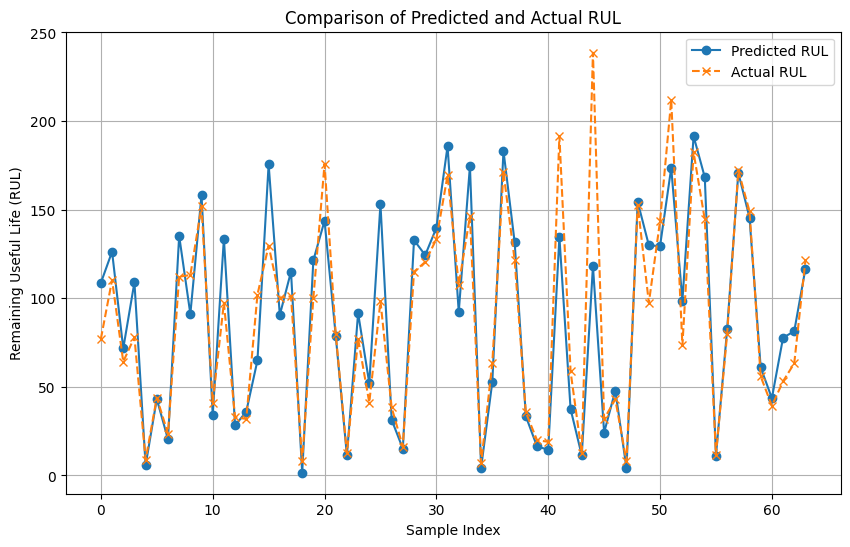

Loss on random batch: 0.005472022108733654


In [101]:
batch_loader = next(iter(validation_loader))

loss, _, _ = predict_on_batch(
    model=centralize_transformer_model,
    batch_loader=batch_loader,
    return_actual_rul=True,
    show_fig=True,
)
print(f'Loss on random batch: {loss}')

# Part II. Setup Federated Learning with Flower for RUL prediction using Transformer model

### Define parameters for training FL with Flower

In [102]:
num_clients = 10
num_rounds = 50

### Split dataframe to 10 subframe for 10 client

In [109]:
def split_dataset(dataset, num_clients):
    """
    Chia dataset thành num_clients tập con đều nhau.
    Args:
        dataset: Dataset cần chia (torch.utils.data.Dataset).
        num_clients: Số lượng tập con muốn tạo.
    Returns:
        List chứa các tập con của dataset.
    """
    # Kích thước mỗi tập con
    subset_size = len(dataset) // num_clients
    sizes = [subset_size] * num_clients

    # Chia phần dư (nếu tổng dataset không chia hết)
    sizes[-1] += len(dataset) - sum(sizes)

    # Tạo danh sách các tập con
    subsets = random_split(dataset, sizes)
    return subsets

In [104]:
# train.head()
train.shape

(20631, 27)

In [110]:
data = CMAPSSLoaderDataset(train, sequence_length=sequence_length)
train_data, validation_data = train_test_split(data, test_size=0.2, random_state=42)

subset_trains = split_dataset(train_data, num_clients=num_clients)
subset_validations = split_dataset(validation_data, num_clients=num_clients)

client_loader_trains = [DataLoader(subset, batch_size=batch_size, shuffle=True) for subset in subset_trains]
client_loader_validations = [DataLoader(subset, batch_size=batch_size, shuffle=True) for subset in subset_validations]

In [111]:
for i, loader in enumerate(client_loader_trains):
    print(f"Client {i+1} will use a subset with {len(loader.dataset)} samples")

Client 1 will use a subset with 1418 samples
Client 2 will use a subset with 1418 samples
Client 3 will use a subset with 1418 samples
Client 4 will use a subset with 1418 samples
Client 5 will use a subset with 1418 samples
Client 6 will use a subset with 1418 samples
Client 7 will use a subset with 1418 samples
Client 8 will use a subset with 1418 samples
Client 9 will use a subset with 1418 samples
Client 10 will use a subset with 1422 samples


In [112]:
for i, loader in enumerate(client_loader_trains):
    print(f"Client {i+1} will use a subset with {len(loader.dataset)} samples")

Client 1 will use a subset with 1418 samples
Client 2 will use a subset with 1418 samples
Client 3 will use a subset with 1418 samples
Client 4 will use a subset with 1418 samples
Client 5 will use a subset with 1418 samples
Client 6 will use a subset with 1418 samples
Client 7 will use a subset with 1418 samples
Client 8 will use a subset with 1418 samples
Client 9 will use a subset with 1418 samples
Client 10 will use a subset with 1422 samples


### Update model parameters

In [113]:
def set_parameters(model, parameters: List[np.ndarray]):
    params_dict = zip(model.state_dict().keys, parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

def get_parameters(model) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

### Define the Flower ClientApp

In [121]:
class FlowerClient(NumPyClient):
    def __init__(self, model, client_loader_train, client_loader_validation):
        self.model = model
        self.trainloader = client_loader_train
        self.valloader = client_loader_validation

    def get_parameters(self, config):
        return get_parameters(self.model)
    
    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        train_model(
            model=self.model,
            client_loader_train=self.trainloader,
            client_loader_validation=self.valloader,
            epochs=1,
            learning_rate=learning_rate,
            verbose=verbose,
        )
        return get_parameters(self.model), len(self.trainloader), {}
    
    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        # loss, accuracy = test_model(self.model, self.valloader)
        loss = test(
            model=self.model,
            client_loader_validation=self.valloader,
            return_actual_rul=False,
            show_fig=False
        )
        return float(loss), len(self.valloader), {'accuracy': float(0.0)}

In [122]:
def client_fn(context: Context) -> Client:
    """Create a Flower client representing a single organization"""
    # Define model
    model = TransformerModel(
        input_dim=input_dim,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=0.1
    ).to(DEVICE)

    # Load data
    # Note: each client gets a different trainloader/valloader, so each client
    # will train and evaluate on their own unique data partition
    # Read the node_config to fetch data partition associated to this node
    partition_id = context.node_config['partition-id']
    trainloader = client_loader_trains[partition_id]
    valloader = client_loader_validations[partition_id]

    # Create a single Flower client representing a single organization
    # FlowerClient is a subclass of NumPyClient, so we need to call .to_client()
    return FlowerClient(model, trainloader, valloader).to_client()


# Create the ClientApp
client = ClientApp(client_fn=client_fn)

### Define the Flower ServerApp

In [123]:
# Create FedAvg strategy
strategy = FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.5,
    min_fit_clients=10,
    min_evaluate_clients=5,
    min_available_clients=10
)

In [127]:
def server_fn(context: Context) -> ServerAppComponents:
    """Construct components that set the ServerApp behaviour.
    
    You can use the setting in `context.run_config` to parameterize the
    construction of all elements (e.g the strategy or the number oof rounds)
    wrapped in the returned ServerAppComponents object."""

    # configure the server for n rounds of training
    config = ServerConfig(num_rounds=num_rounds)
    return ServerAppComponents(strategy=strategy, config=config)

# Create the ServerApp
server = ServerApp(server_fn=server_fn)

### Run the training

In [128]:
# Specify the resources each of your clients need
# By default, each client will be allocated 1x and 0x GPUs
backend_config = {'client_resources': {'num_cpus': 1, 'num_gpus': 0.0}}

# When running on GPU, assign an entire GPU for each client
if DEVICE.type == "cuda":
    backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 1.0}}
    # Refer to our Flower framework documentation for more details about Flower simulation
    # and how to set up the 'backend_config+

In [ ]:
# Run simulation
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=num_clients,
    backend_config=backend_config
)

INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client


(ClientAppActor pid=1492) e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
(ClientAppActor pid=1492)   warnings.warn(
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)
ERROR :     An exception was raised when processing a message by RayBackend
ERROR :     An exception was raised when processing a message by RayBackend
ERROR :     An exception was raised when processing a message by RayBackend
(ClientAppActor pid=4612) e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is Fals